# Exploratory Data Analysis: Tokamak Telemetry

For checking if the LSTM accurately mimics the physical precursors of a plasma disruption.

This notebook:
1. Generate a batch of synthetic plasma telemetry.
2. Isolate a stable plasma sequence and a disruptive sequence.
3. Visually compare the 5 core diagnostic features to ensure the physical instability signatures (e.g., $q$-factor drop, MHD mode growth) are present.

In [3]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Add the src directory to the system path to import custom modules
sys.path.append(os.path.abspath('../src'))

from data_generator import generate_synthetic_plasma_data

plt.style.use('seaborn-v0_8-darkgrid')

### 1. Generate Telemetry
We will generate a small batch of 100 sequences, each 50 milliseconds (time steps) long, containing our 5 diagnostic features.

In [8]:
import yaml

# 1. Load the configuration file
config_path = os.path.abspath('../config.yaml')
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

# Extract variables dynamically
SEQ_LENGTH = config['data']['seq_length']
NUM_SAMPLES = 100 # (hardcoded for visualization)

print(f"Loaded config: Sequence Length = {SEQ_LENGTH}")

# 2. Generate data
X, y = generate_synthetic_plasma_data(num_samples=NUM_SAMPLES, seq_length=SEQ_LENGTH)

print(f"Feature Matrix Shape: {X.shape} -> (Batch, Time Steps, Features)")
print(f"Labels Shape: {y.shape}")

# 3. Find the indices of the first stable and first disruptive sequence
stable_idx = np.where(y.numpy() == 0)[0][0]
disrupt_idx = np.where(y.numpy() == 1)[0][0]

stable_seq = X[stable_idx].numpy()
disrupt_seq = X[disrupt_idx].numpy()

Loaded config: Sequence Length = 50
Feature Matrix Shape: torch.Size([100, 50, 5]) -> (Batch, Time Steps, Features)
Labels Shape: torch.Size([100])


### 2. Visualizing the Physics
In a **stable** plasma, parameters should maintain a steady baseline with minor random-walk sensor noise. 

In a **disruptive** plasma, we expect to see the following in the final 20 time steps:
* **Plasma Beta** exceeding the Troyon limit (Pressure-driven instability).
* **Safety Factor ($q$)** dropping dangerously close to 2.0 (Current-driven kink/tearing modes).
* **MHD Amplitude** growing exponentially (Magnetic islands locking and growing).

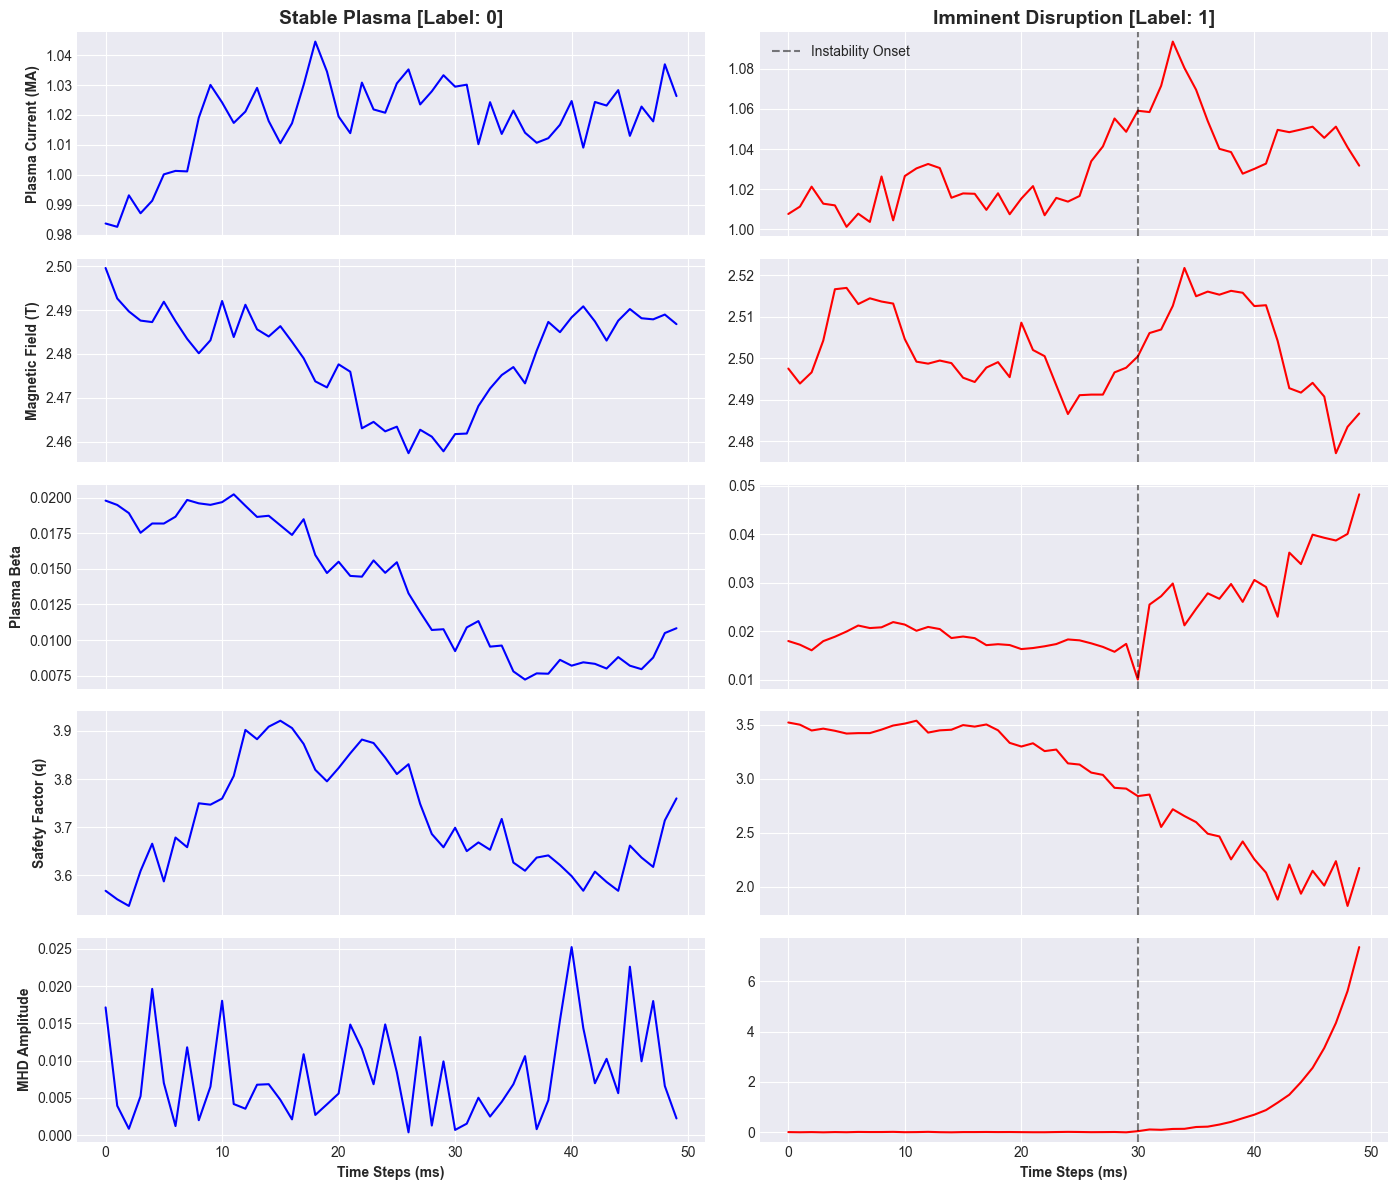

In [ ]:
feature_names = [
    "Plasma Current (MA)", 
    "Magnetic Field (T)", 
    "Plasma Beta", 
    "Safety Factor (q)", 
    "MHD Amplitude"
]

time_steps = np.arange(SEQ_LENGTH)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 12), sharex=True)

# Plot Stable Sequence (Left Column)
for i in range(5):
    axes[i, 0].plot(time_steps, stable_seq[:, i], color='blue')
    axes[i, 0].set_ylabel(feature_names[i], fontweight='bold')
    if i == 0:
        axes[i, 0].set_title("Stable Plasma [Label: 0]", fontsize=14, fontweight='bold')
    if i == 4:
        axes[i, 0].set_xlabel("Time Steps (ms)", fontweight='bold')

# Plot Disruptive Sequence (Right Column)
for i in range(5):
    axes[i, 1].plot(time_steps, disrupt_seq[:, i], color='red')
    # Vertical line indicates the start of the disruption precursor window
    axes[i, 1].axvline(x=30, color='black', linestyle='--', alpha=0.5, label='Instability Onset')
    
    if i == 0:
        axes[i, 1].set_title("Imminent Disruption [Label: 1]", fontsize=14, fontweight='bold')
        axes[i, 1].legend(loc='upper left')
    if i == 4:
        axes[i, 1].set_xlabel("Time Steps (ms)", fontweight='bold')

plt.tight_layout()

save_path = os.path.join(os.getcwd(), "../media/feature_exploration.png")
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print(f"Visualization saved successfully to: {save_path}")

plt.show()